# Mathematical Engineering - Financial Engineering, FY 2025-2026
# Risk Management - Exercise 5: Extended Vasiceck model Monte Carlo simulation for CCR estimation

#### Import the libraries and functions needed created in previous labs

In [12]:
# Importing the libraries
import os
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from utilities.date_functions import (
    business_date_offset,
    date_series,
    year_frac_act_x,
    year_frac_30e_360
)

from utilities.ex0_utilities import (
    bootstrap,
    from_discount_factors_to_zero_rates,
    get_discount_factor_by_zero_rates_linear_interp)

from utilities.ex1_utilities import (
    swap_par_rate,
    SwapType
)

from utilities.ex5_utilities import (
    simulate_ou_process,
    affine_trick,
    update_collateral
)

#### Bootstrap 

In [13]:
data_path = Path("data")
today = pd.Timestamp(2008, 2, 19)

# Dates
dt = pd.read_csv(
    data_path / "dt.csv",
    index_col='Market',
    usecols=['Market', 'TARGET'],
    converters={'TARGET': pd.to_datetime}
)

settlement_date = dt.loc['Settlement', 'TARGET']

# Depos
depo_converter = lambda x: float(x) / 100.0

df_depos = pd.read_csv(
    data_path / "depos.csv",
    index_col='Depos',
    usecols=['Depos', 'ASK', 'BID'],
    converters={
        'Depos': pd.to_datetime,
        'BID': depo_converter,
        'ASK': depo_converter
    }
)

# Futures
future_converter = lambda x: float(x)

futures = pd.read_csv(
    data_path / "futures.csv",
    index_col='Futures',
    usecols=['Futures', 'ASK', 'BID'],
    converters={
        'Futures': pd.to_datetime,
        'BID': future_converter,
        'ASK': future_converter
    }
)

expiry = pd.read_csv(
    data_path / "expiry.csv",
    index_col='Futures',
    usecols=['Futures', 'Settle', 'Expiry'],
    converters={
        'Futures': pd.to_datetime,
        'Settle': pd.to_datetime,
        'Expiry': pd.to_datetime
    }
)

df_futures = futures.join(expiry)

# Swaps
swap_converter = lambda x: float(x)

df_swaps = pd.read_csv(
    data_path / "swaps.csv",
    index_col='Swaps',
    usecols=['Swaps', 'BID', 'ASK'],
    converters={
        'Swaps': pd.to_datetime,
        'BID': swap_converter,
        'ASK': swap_converter
    }
)

# Bootstrap
discount_factors, zero_rates = bootstrap(
    settlement_date,
    df_depos,
    df_futures,
    df_swaps
)

display(discount_factors)

2008-02-19    1.000000
2008-02-20    0.999889
2008-02-26    0.999209
2008-03-19    0.996664
2008-06-19    0.985787
2008-09-18    0.976098
2008-12-17    0.967330
2009-03-17    0.959005
2009-06-18    0.950661
2009-09-17    0.942498
2009-12-16    0.934302
2010-02-19    0.926897
2011-02-21    0.891615
2012-02-20    0.855991
2013-02-19    0.819887
2014-02-19    0.783754
2015-02-19    0.747803
2016-02-19    0.712371
2017-02-20    0.677734
2018-02-19    0.644301
2019-02-19    0.612067
2020-02-19    0.581076
2021-02-19    0.551908
2022-02-21    0.523910
2023-02-20    0.497609
2024-02-19    0.472737
2025-02-19    0.449183
2026-02-19    0.426982
2027-02-19    0.406056
2028-02-21    0.386237
2029-02-19    0.367744
2030-02-19    0.350232
2031-02-19    0.333729
2032-02-19    0.318187
2033-02-21    0.303477
2034-02-20    0.289728
2035-02-19    0.276763
2036-02-19    0.264486
2037-02-19    0.252890
2038-02-19    0.241918
2039-02-21    0.231456
2040-02-20    0.221611
2041-02-19    0.212275
2042-02-19 

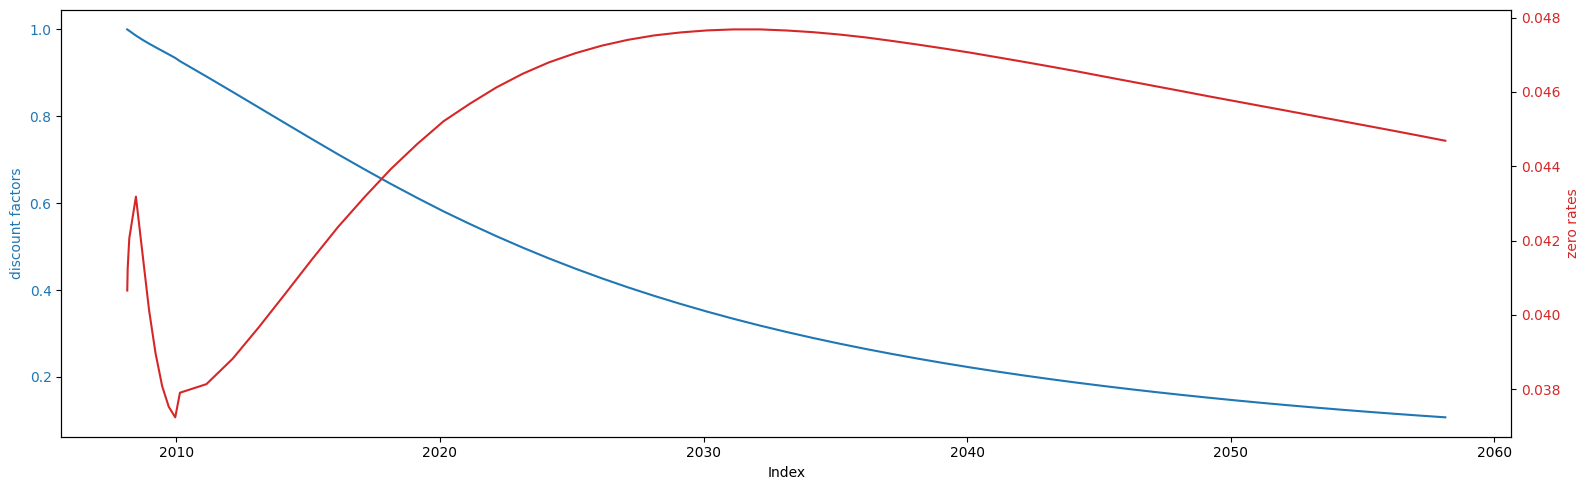

In [14]:
fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(discount_factors.index, discount_factors.values, color='tab:blue')
ax1.set_ylabel('discount factors', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(zero_rates.index, zero_rates.values, color='tab:red')
ax2.set_ylabel('zero rates', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_xlabel('Index')
plt.tight_layout()

plt.show()


#### MonteCarlo grid set up

In [ ]:
# Monte Carlo Simulations parameters, grids and outputs to store
np.random.seed(42)   #we need to set the seed 
# params
simulations_num = 100_000
years_to_simulate = 10

# last point on the simulation grid
simulations_expiry = business_date_offset(settlement_date, month_offset=years_to_simulate) 

# 40 simulation dates (t_0 non a simulation date)
total_point = 40
point_per_year = total_point//years_to_simulate
simulation_grid = date_series(settlement_date, simulations_expiry, point_per_year)[1:]


# output to compute
expected_positive_exposure = pd.DataFrame(
    data=0.0, index=simulation_grid, columns=["base", "break", "no netting", "netting", "collateral"])

alpha = 0.95
potential_future_exposure = pd.DataFrame(
    data=0.0, index=simulation_grid, columns=["base", "break", "no netting", "netting", "collateral"]
)

#### Set up of the base contract

In [16]:
####### 10 y payer swap #######

# Parameters for the 10y payer swap
notional = 100_000_000
swap_type = SwapType.PAYER
maturity = 10
fixed_freq = 1 # annual

# !!! COMPLETE AS APPROPRIATE !!!
expiry = None # expiry date
fixed_leg_payment_dates = None

# assume swap traded at par
swap_rate = None

# fixed leg cash flows
irs_cash_flows = pd.Series(
    data=[
        swap_rate
        for count in range(1, len(fixed_leg_payment_dates))],
                
    index=fixed_leg_payment_dates[1:])


# fixed leg cash flows extended on simulation grid
# verify that all the payments fall on a t already included in the simulation grid
irs_cash_flows_extended = (
    irs_cash_flows
    .reindex(simulation_grid, fill_value=0.0)
)

TypeError: object of type 'NoneType' has no len()

#### Set up of the alternative scenarios 

In [ ]:
# a) mandatory break clause
# Set up of the break date
break_year = 3
break_month = 6

# !!! COMPLETE AS APPROPRIATE !!!
break_expiry = None # break date


# b) 5 y payer swap
# Parameters for the 5y receiver swap
# swap 2 has fixed leg quarterly, float leg quarterly (euribor 3m), same yf conventions of base swap
notional_2 = 150_000_000
swap_type_2 = SwapType.RECEIVER
maturity_2 = 5
fixed_freq_2 = 4 

# !!! COMPLETE AS APPROPRIATE !!!
expiry_2 = None
fixed_leg_payment_dates_2 = None

# assume swap traded at par
swap_rate_2 = None

# fixed leg cash flows
irs_cash_flows_2 = pd.Series(
    data=[
        swap_rate_2
        for count in range(1, len(fixed_leg_payment_dates_2))],
                
    index=fixed_leg_payment_dates_2[1:])


# fixed leg cash flows extended on simulation grid
irs_cash_flows_extended_2 = (
    irs_cash_flows_2
    .reindex(simulation_grid, fill_value=0.0)
)



# c) CSA agreement
# No IA, no rounding, no haircut, no delay in the posting of the collateral (i.e. margin call done at t -> new collateral posted at t)
# CSA parameters for party B (Polimi Bank)

# !!! COMPLETE AS APPROPRIATE !!!
THR_B = None
MTA_B = 0      # given, choose correctly the other parameters
Cap_B = np.inf # given, choose correctly the other parameters

THR_C = None 
MTA_C = 0      # given, choose correctly the other parameters
Cap_C = None

#### x_t OU Process simulations

In [ ]:
# OU process parameters

mean_reversion = 0.0205
sigma = 0.0094

In [ ]:
x_paths = simulate_ou_process(simulation_grid,
                              settlement_date, 
                              mean_reversion, 
                              sigma, 
                              simulations_num,
                              x0=0)

#### From OU to discount factors and MtM and exposures

In [ ]:
# Inizialization of zero rates
zero_rates = (
    zero_rates.reindex(zero_rates.index.union([simulation_grid[0]]))
    .sort_index()
    .interpolate(method="index")
)

# Inizialization collateral
collateral_posted = np.zeros(simulations_num)
risk_free_rate = np.full(simulations_num, zero_rates.loc[simulation_grid[0]])
last_collateral_posting_date = settlement_date


# !!! COMPLETE AS APPROPRIATE !!! 
for i, sim_date in enumerate(simulation_grid[0:]):

    prev_date = None
    dt = year_frac_act_x(prev_date, sim_date, 360)

    # Market simulation at time sim_date
    x_t = None

    # A and C changes at each sim_date, but are common across simulations
    A, C = None

    # discounts factor (sim_date,t_j) in each scenario, for each t_j in the simulation_grid, use the affine formula
    discount_factors_hw = None 
    
    # discounted cashflows 
    discounted_cash_flows = None

    # mark-to-future (MtM_t)
    MtF = notional * discounted_cash_flows 

    # remunerate the collateral posted
    collateral_posted *= np.exp(risk_free_rate * year_frac_act_x(prev_date, sim_date, 360))

    if (sim_date - last_collateral_posting_date).days >= 360:
        last_collateral_posting_date = None
        collateral_posted = update_collateral(MtF,collateral_posted,THR_B,THR_C,MTA_B,MTA_C,Cap_B,Cap_C)
    
    MtF_coll = None

    # Positive exposure
    MtF_pos = None
    MtF_pos_coll = None

    
    # Expected exposure
    expected_positive_exposure.loc[sim_date, "base"] = None
    expected_positive_exposure.loc[sim_date, "collateral"] = None
    

    # Potential future exposure
    potential_future_exposure.loc[sim_date, "base"] = None
    potential_future_exposure.loc[sim_date, "collateral"] = None

    # Risk-free rate update
    if i < len(simulation_grid) - 1:
        
        idx = A.index.get_loc(sim_date)

        future_dfs = None

        year_fracs = None
        
        # use the shortest maturity zero rate
        risk_free_rate = -np.log(future_dfs[0]) / year_fracs[0]

#### Peak PFE

In [ ]:
# Compute for each scenario the peak-PFE and the t at which it materialize
peak_pfe = pd.DataFrame(data = 0, index=["base", "break", "no netting", "netting", "collateral"], columns = ['t','Peak_PFE'])
peak_pfe['Peak_PFE'] = None
peak_pfe['t']= None

#### PLOT 

In [ ]:
### plot 6 a
plt.figure(figsize=(15, 5))
expected_positive_exposure[['base','break']].plot()
plt.title(f"Expected Positive Exposure with and without BC")
plt.grid()
plt.show()

plt.figure(figsize=(15, 5))
potential_future_exposure[['base','break']].plot()
plt.title(f"Potential Future Exposure with and without BC")
plt.grid()
plt.show()

### plot 6 b

### plot 6 c


#### CVA estimations

In [ ]:
# Parameters
hazard_rate = 0.02
lgd = 0.6

In [ ]:
# !!! COMPLETE AS APPROPRIATE !!! 
